# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [2]:
data = pd.read_csv("/kaggle/input/amazon-fine-food-reviews/Reviews.csv", nrows=5000)


# Explore the Data

In [3]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
data.shape

(5000, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [6]:
data.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2500.500000,1.580200,2.067200,4.150400,1.294930e+09
std,1443.520003,5.584533,6.288672,1.326549,4.802063e+07
min,1.000000,0.000000,0.000000,1.000000,9.617184e+08
25%,1250.750000,0.000000,0.000000,4.000000,1.271376e+09
50%,2500.500000,0.000000,1.000000,5.000000,1.309219e+09
75%,3750.250000,2.000000,2.000000,5.000000,1.330301e+09
max,5000.000000,187.000000,216.000000,5.000000,1.351210e+09


# Handle Missing Values

In [7]:
data.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [8]:
data.dropna(inplace=True)

# Handle Duplicates

In [9]:
data.duplicated().sum()

0

In [10]:
data.drop_duplicates(inplace=True)

# Convert Data Types

In [11]:
data["Time"] = pd.to_datetime(data["Time"], unit="s")

In [12]:
data["Time"]

0      2011-04-27
1      2012-09-07
2      2008-08-18
3      2011-06-13
4      2012-10-21
          ...    
4995   2012-07-03
4996   2012-07-01
4997   2012-05-11
4998   2012-07-13
4999   2012-05-26
Name: Time, Length: 5000, dtype: datetime64[ns]

# Feature Engineering

In [13]:
data['HelpfulnessRatio'] = data['HelpfulnessNumerator'] / data['HelpfulnessDenominator']

In [14]:
data['HelpfulnessRatio']

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


0       1.0
1       NaN
2       1.0
3       1.0
4       NaN
       ... 
4995    1.0
4996    1.0
4997    1.0
4998    NaN
4999    NaN
Name: HelpfulnessRatio, Length: 5000, dtype: float64

In [15]:
data['ReviewLength'] = data['Text'].apply(lambda x: len(x.split()))

In [16]:
data['ReviewLength']

0        48
1        31
2        94
3        41
4        27
       ... 
4995    105
4996    121
4997    105
4998    120
4999    139
Name: ReviewLength, Length: 5000, dtype: int64

In [17]:
data['SummaryWordCount'] = data['Summary'].apply(lambda x: len(x.split()))

In [18]:
data['SummaryWordCount']

0        4
1        3
2        4
3        2
4        2
        ..
4995     6
4996    11
4997     7
4998     8
4999     3
Name: SummaryWordCount, Length: 5000, dtype: int64

In [19]:
from textblob import TextBlob
data['SentimentScore'] = data['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [20]:
data['SentimentScore']

0       0.450000
1      -0.033333
2       0.133571
3       0.166667
4       0.483333
          ...   
4995   -0.083333
4996    0.302273
4997    0.354615
4998    0.345417
4999    0.189796
Name: SentimentScore, Length: 5000, dtype: float64

In [21]:
data['ReviewAge'] = (pd.Timestamp.now() - data['Time']).dt.days

In [22]:
data['ReviewAge']

0       5111
1       4612
2       6093
3       5064
4       4568
        ... 
4995    4678
4996    4680
4997    4731
4998    4668
4999    4716
Name: ReviewAge, Length: 5000, dtype: int64

In [23]:
    data['DayOfWeek'] = data['Time'].dt.dayofweek

In [24]:
data['DayOfWeek']

0       2
1       4
2       0
3       0
4       6
       ..
4995    1
4996    6
4997    4
4998    4
4999    5
Name: DayOfWeek, Length: 5000, dtype: int32

In [25]:
data['Month'] = data['Time'].dt.month

# Text Preprocessing

In [26]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

def preprocessing_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

data['CleanedSummary'] = data['Summary'].apply(preprocessing_text)
data['CleanedText'] = data['Text'].apply(preprocessing_text)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [27]:
data['CleanedSummary']

0               good quality dog food
1                          advertised
2                        delight says
3                      cough medicine
4                         great taffy
                    ...              
4995             cavemen must wealthy
4996      cookies need work make home
4997                 okay pinch great
4998    good except rainforest flavor
4999              great healthy snack
Name: CleanedSummary, Length: 5000, dtype: object

In [28]:
data['CleanedText']

0       bought several vitality canned dog food produc...
1       product arrived labeled jumbo salted peanutsth...
2       confection around centuries light pillowy citr...
3       looking secret ingredient robitussin believe f...
4       great taffy great price wide assortment yummy ...
                              ...                        
4995    really wanted like thesebr br first cookies si...
4996    impressed cookies tried first came company one...
4997    cookies came sealed seem high quality ingredie...
4998    taste good arent like best things ever either ...
4999    love cookies paleo diet right cookies look for...
Name: CleanedText, Length: 5000, dtype: object

# Encode Categorical Variables

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['ProfileName'] = le.fit_transform(data['ProfileName'])

# Outlier Detection and Handling

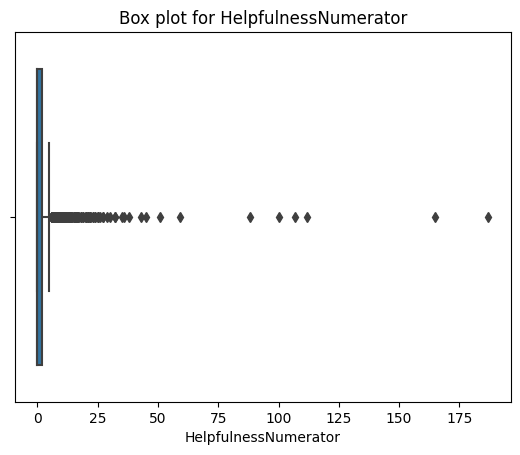

In [30]:
# Box plot for HelpfulnessNumerator
sns.boxplot(x=data['HelpfulnessNumerator'])
plt.title('Box plot for HelpfulnessNumerator')
plt.show()

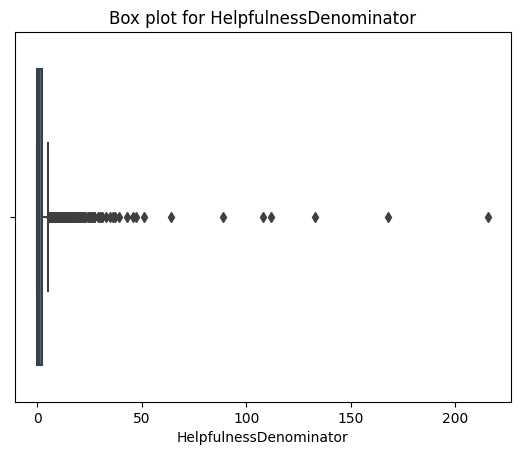

In [31]:
# Box plot for HelpfulnessDenominator
sns.boxplot(x=data['HelpfulnessDenominator'])
plt.title('Box plot for HelpfulnessDenominator')
plt.show()

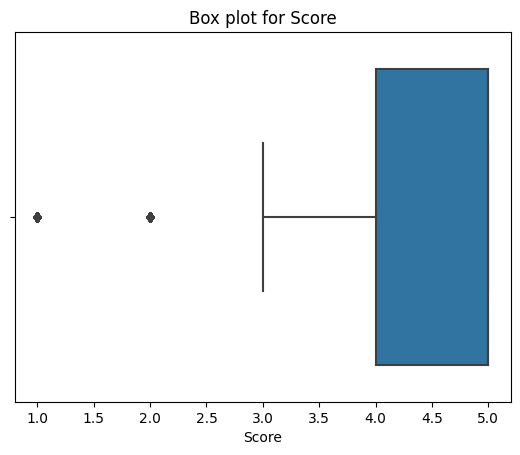

In [32]:
# Box plot for Score
sns.boxplot(x=data['Score'])
plt.title('Box plot for Score')
plt.show()

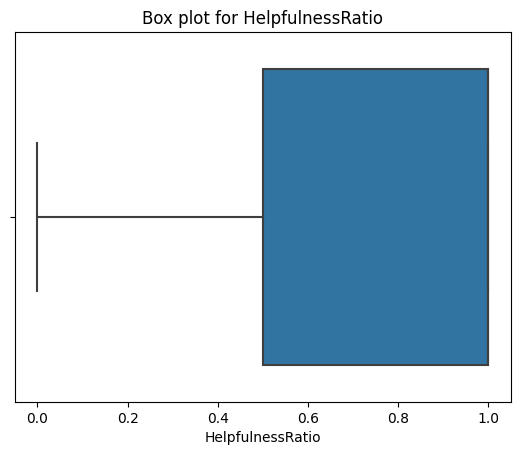

In [33]:
# Box plot for HelpfulnessRatio
sns.boxplot(x=data['HelpfulnessRatio'])
plt.title('Box plot for HelpfulnessRatio')
plt.show()

In [34]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for HelpfulnessNumerator
Q1_num = data['HelpfulnessNumerator'].quantile(0.25)
Q3_num = data['HelpfulnessNumerator'].quantile(0.75)

# Calculate IQR for HelpfulnessNumerator
IQR_num = Q3_num - Q1_num

# Define lower and upper bound for HelpfulnessNumerator
lower_bound_num = Q1_num - 1.5 * IQR_num
upper_bound_num = Q3_num + 1.5 * IQR_num

# Identify outliers for HelpfulnessNumerator
outliers_num = data[(data['HelpfulnessNumerator'] < lower_bound_num) | (data['HelpfulnessNumerator'] > upper_bound_num)]

#  remove outliers for HelpfulnessNumerator
data_cleaned_num = data[~((data['HelpfulnessNumerator'] < lower_bound_num) | (data['HelpfulnessNumerator'] > upper_bound_num))]

print(f"Number of outliers in HelpfulnessNumerator: {len(outliers_num)}")

Number of outliers in HelpfulnessNumerator: 304


In [35]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for HelpfulnessDenominator
Q1_denom = data['HelpfulnessDenominator'].quantile(0.25)
Q3_denom = data['HelpfulnessDenominator'].quantile(0.75)

# Calculate IQR for HelpfulnessDenominator
IQR_denom = Q3_denom - Q1_denom

# Define lower and upper bound for HelpfulnessDenominator
lower_bound_denom = Q1_denom - 1.5 * IQR_denom
upper_bound_denom = Q3_denom + 1.5 * IQR_denom

# Identify outliers for HelpfulnessDenominator
outliers_denom = data[(data['HelpfulnessDenominator'] < lower_bound_denom) | (data['HelpfulnessDenominator'] > upper_bound_denom)]

# Optionally, remove outliers for HelpfulnessDenominator
data_cleaned_denom = data[~((data['HelpfulnessDenominator'] < lower_bound_denom) | (data['HelpfulnessDenominator'] > upper_bound_denom))]

print(f"Number of outliers in HelpfulnessDenominator: {len(outliers_denom)}")

Number of outliers in HelpfulnessDenominator: 449


# Data Scaling

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']] = scaler.fit_transform(data[['HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']])

In [37]:
data[['HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,HelpfulnessNumerator,HelpfulnessDenominator,HelpfulnessRatio
0,-0.103904,-0.169719,0.673086
1,-0.282988,-0.328751,NaN
2,-0.103904,-0.169719,0.673086
3,0.254263,0.148345,0.673086
4,-0.282988,-0.328751,NaN
...,...,...,...
4995,-0.103904,-0.169719,0.673086
4996,-0.103904,-0.169719,0.673086
4997,-0.103904,-0.169719,0.673086
4998,-0.282988,-0.328751,NaN


# Data Visualization

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


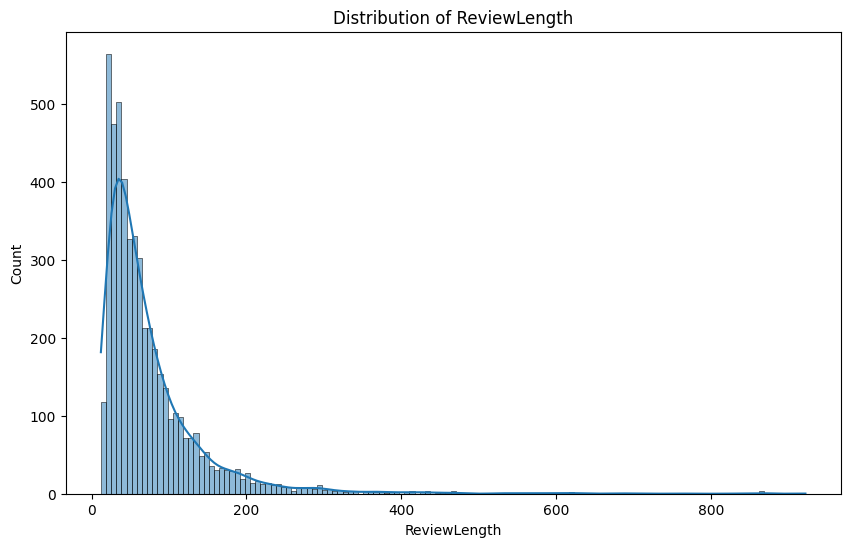

In [38]:
# Distribution of ReviewLength
plt.figure(figsize=(10, 6))
sns.histplot(data['ReviewLength'], kde=True)
plt.title('Distribution of ReviewLength')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


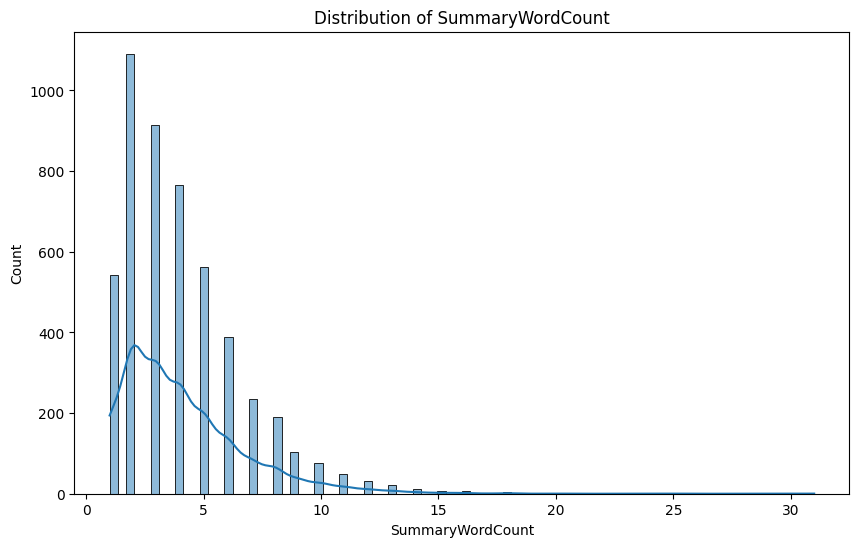

In [39]:
# Distribution of SummaryWordCount
plt.figure(figsize=(10, 6))
sns.histplot(data['SummaryWordCount'], kde=True)
plt.title('Distribution of SummaryWordCount')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


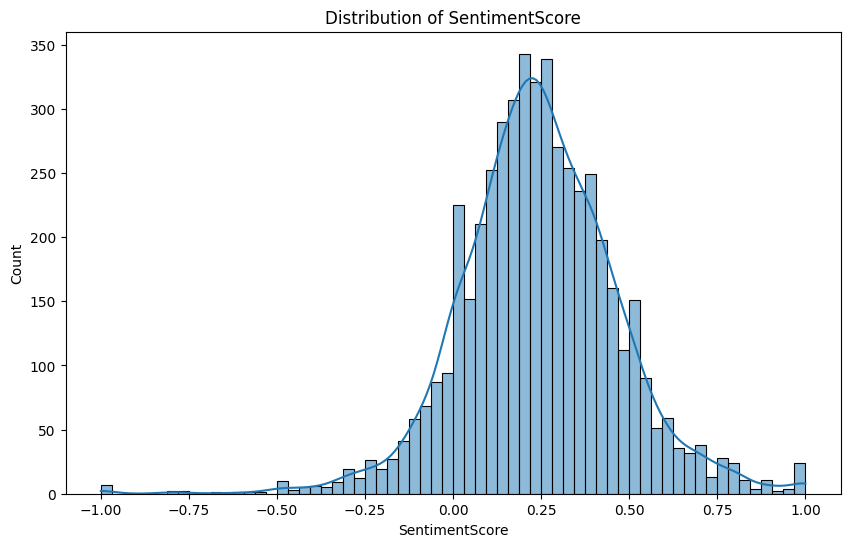

In [40]:
# Distribution of SentimentScore
plt.figure(figsize=(10, 6))
sns.histplot(data['SentimentScore'], kde=True)
plt.title('Distribution of SentimentScore')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


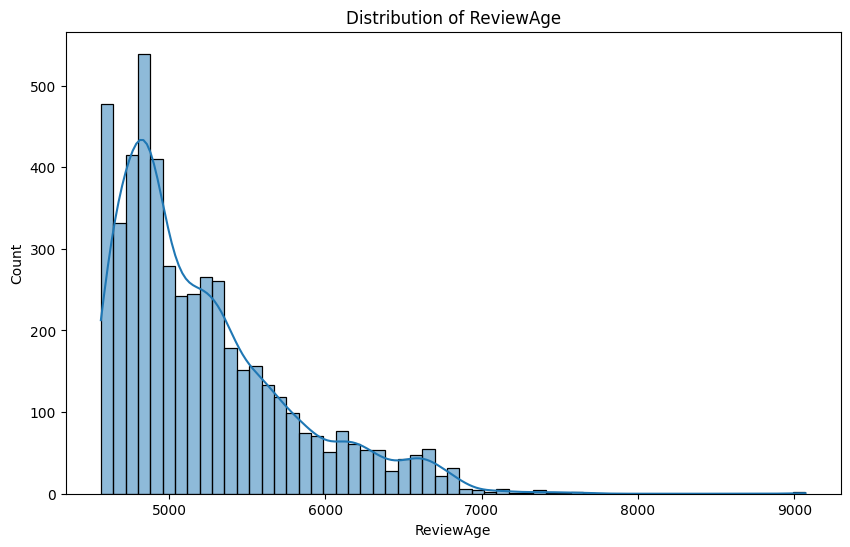

In [41]:
# Distribution of ReviewAge
plt.figure(figsize=(10, 6))
sns.histplot(data['ReviewAge'], kde=True)
plt.title('Distribution of ReviewAge')
plt.show()

1. Visualize Categorical Data

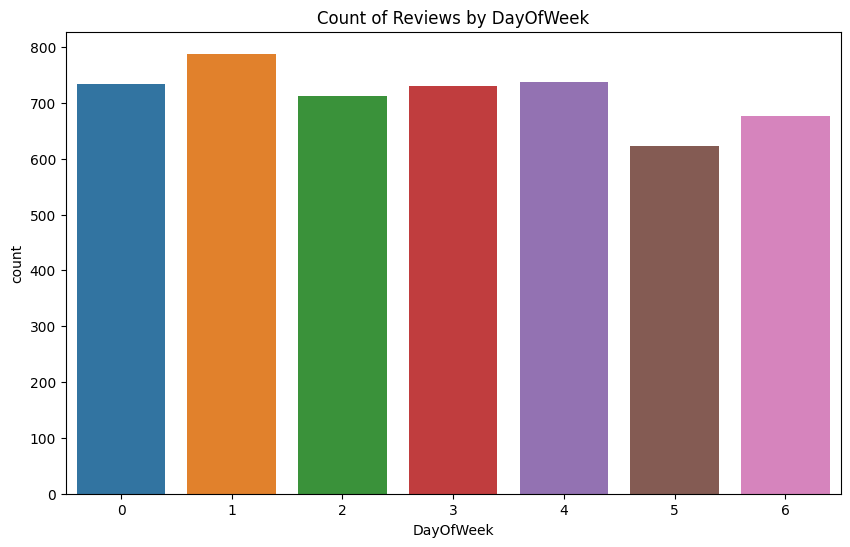

In [42]:
# Bar plot for DayOfWeek
plt.figure(figsize=(10, 6))
sns.countplot(x=data['DayOfWeek'])
plt.title('Count of Reviews by DayOfWeek')
plt.show()

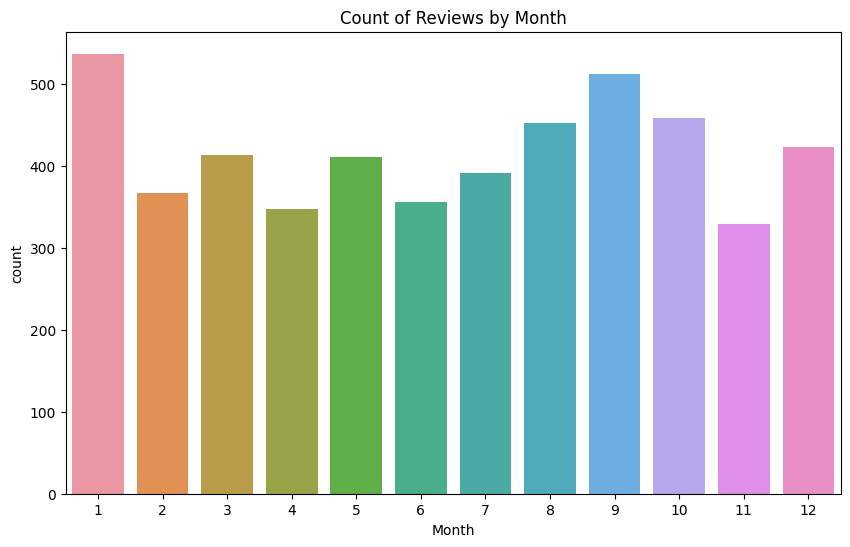

In [43]:
# Bar plot for Month
plt.figure(figsize=(10, 6))
sns.countplot(x=data['Month'])
plt.title('Count of Reviews by Month')
plt.show()

2. Visualize Relationships Between Two Numerical Features 

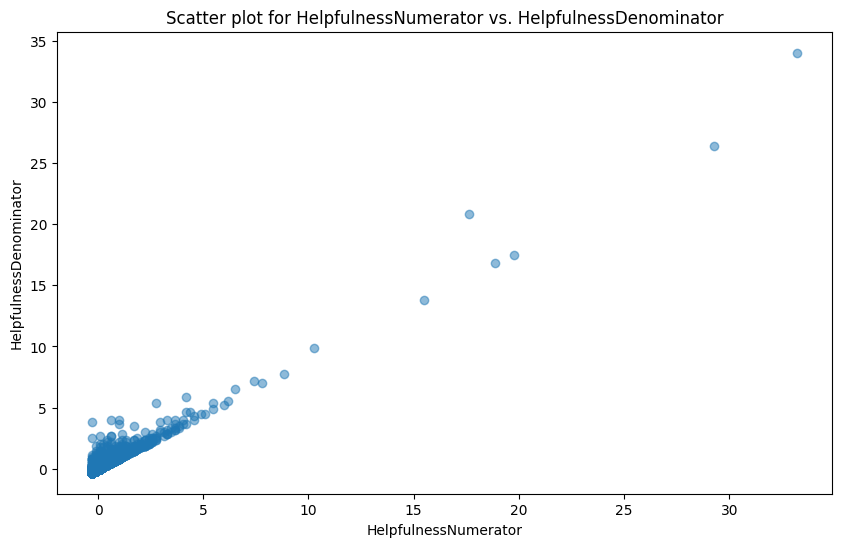

In [44]:
# Scatter plot for HelpfulnessNumerator vs. HelpfulnessDenominator
plt.figure(figsize=(10, 6))
plt.scatter(data['HelpfulnessNumerator'], data['HelpfulnessDenominator'], alpha=0.5)
plt.xlabel('HelpfulnessNumerator')
plt.ylabel('HelpfulnessDenominator')
plt.title('Scatter plot for HelpfulnessNumerator vs. HelpfulnessDenominator')
plt.show()

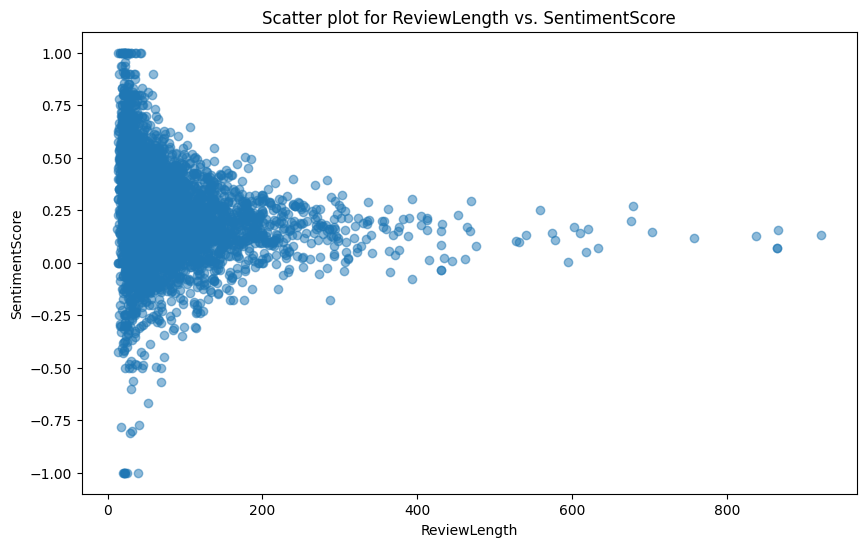

In [45]:
# Scatter plot for ReviewLength vs. SentimentScore
plt.figure(figsize=(10, 6))
plt.scatter(data['ReviewLength'], data['SentimentScore'], alpha=0.5)
plt.xlabel('ReviewLength')
plt.ylabel('SentimentScore')
plt.title('Scatter plot for ReviewLength vs. SentimentScore')
plt.show()

3. Visualize Correlations Between Multiple Features

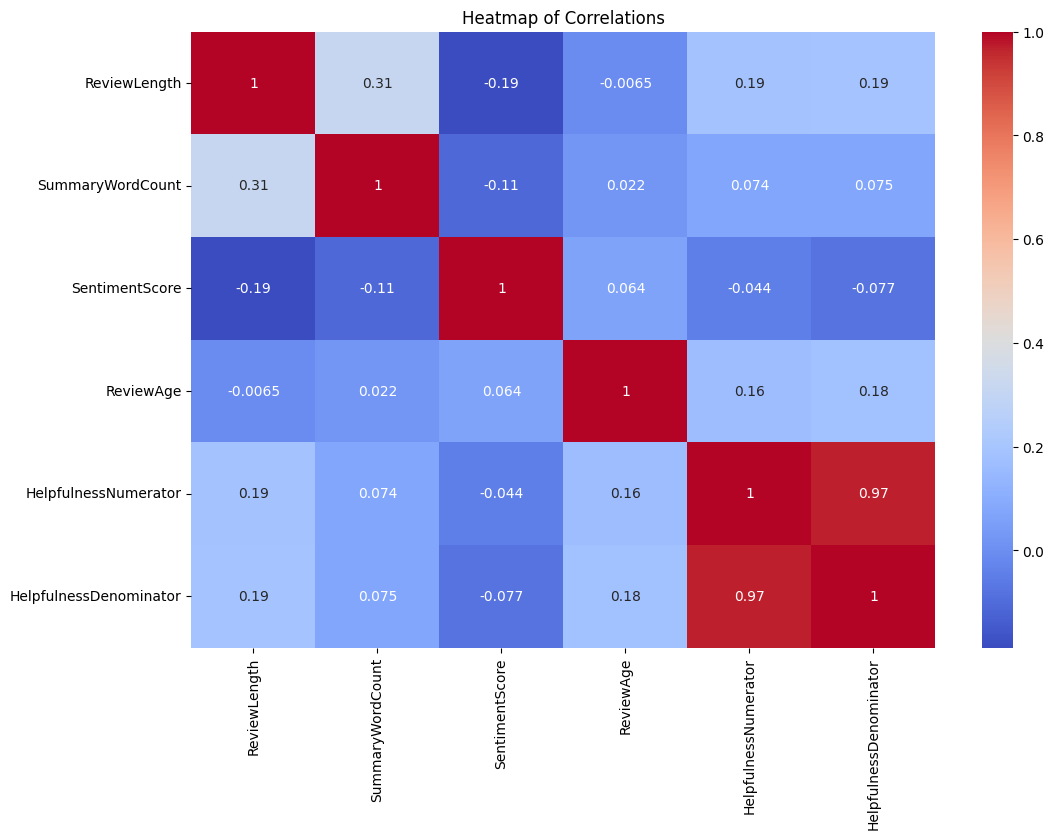

In [46]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(data[['ReviewLength', 'SummaryWordCount', 'SentimentScore', 'ReviewAge', 'HelpfulnessNumerator', 'HelpfulnessDenominator']].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlations')
plt.show()

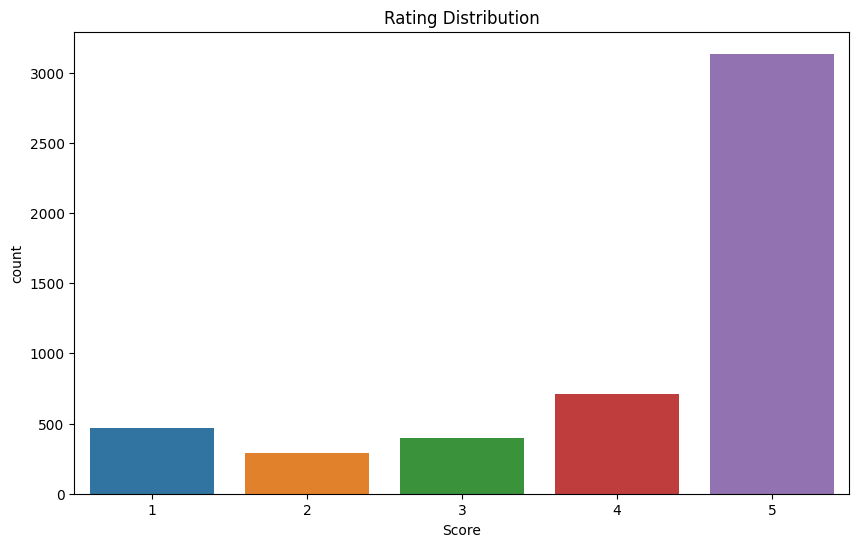

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Score', data=data)
plt.title('Rating Distribution')
plt.show()

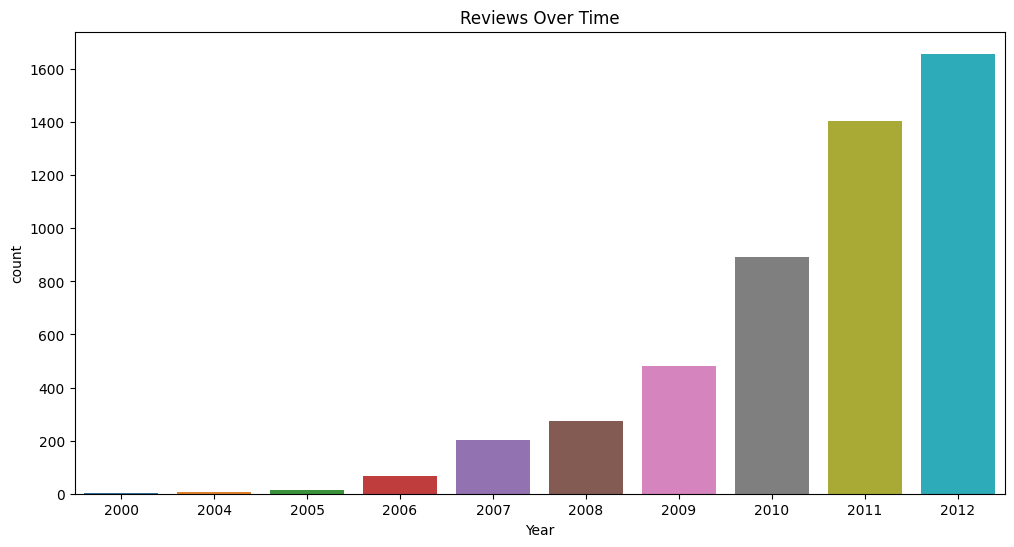

In [48]:
plt.figure(figsize=(12, 6))
data['Year'] = data['Time'].dt.year
sns.countplot(x='Year', data=data)
plt.title('Reviews Over Time')
plt.show()